# Математический аппарат реализованного алгоритма GradientBoostingReg

Реализованный класс выполняет пошаговую минимизацию эмпирического риска методом градиентного бустинга над решающими деревьями регрессии. Ниже приведены все формулы, используемые на каждом этапе работы алгоритма.

---

### 1. Инициализация базового предсказания ($F_0$)
Перед началом обучения ансамбля вычисляется константное стартовое предсказание $F_0(x)$, минимизирующее выбранную функцию потерь на всей обучающей выборке:

* **Для MSE (`loss='mse'`):** Оптимальной константой является среднее арифметическое таргета:
  $$F_0(x) = \frac{1}{n} \sum_{i=1}^{n} y_i$$

* **Для MAE (`loss='mae'`):** Оптимальной константой является медиана таргета:
  $$F_0(x) = \text{median}(y)$$

---

### 2. Расчет псевдоостатков (Антиградиента)
На каждой итерации бустинга $m$ (где $m = 1, \dots, M$) для каждого объекта выборки вычисляется вектор остатков $r_{im}$. Математически это антиградиент — минус первая производная функции потерь по текущему предсказанию ансамбля $F_{m-1}(x_i)$:

$$r_{im} = -\left[ \frac{\partial L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)} \right]$$

* **Для MSE** ($L = \frac{1}{2}(y - F)^2$): Остаток равен чистой ошибке предсказания:
  $$r_{im} = y_i - F_{m-1}(x_i)$$

* **Для MAE** ($L = |y - F|$): Остаток равен направлению (знаку) ошибки, независимо от её масштаба:
  $$r_{im} = \text{sign}(y_i - F_{m-1}(x_i))$$

---

### 3. Обновление предсказаний ансамбля
После того как очередное дерево регрессии $h_m(X)$ обучилось предсказывать вектор остатков $r_m$, текущий массив предсказаний обновляется с учетом шага градиентного спуска (скорости обучения $\eta$):

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

---

### 4. Расчет метрик в истории обучения (`history_loss`)
На каждом шаге для мониторинга сходимости вычисляется среднее значение функции потерь по всей выборке:

* **Для MSE:**
  $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - F_m(x_i))^2$$

* **Для MAE:**
  $$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - F_m(x_i)|$$

---

### 5. Критерий ранней остановки (`stop_gr`)
Обучение прекращается досрочно на шаге $m$, если абсолютное изменение функции потерь между текущей и предыдущей итерациями становится меньше или равно заданному порогу:

$$|L_m - L_{m-1}| \le \text{stop\_gr}$$

---

### 6. Финальное предсказание (`predict`)
Итоговый прогноз для новых данных представляет собой аккумулированную сумму базового значения и взвешенных ответов всех фактически обученных деревьев $M_{\text{final}}$:

$$\hat{y} = F_0(X) + \eta \sum_{m=1}^{M_{\text{final}}} h_m(X)$$


In [18]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class GradientBoostingReg:
    """
    Реализует алгоритм Градиентного Бустинга над решающими деревьями для задач регрессии.

    Модель последовательно строит ансамбль из базовых деревьев регрессии (DecisionTreeRegressor),
    где каждое следующее дерево обучается на антиградиент (остатки) функции потерь относительно
    текущих предсказаний всей системы. Модель поддерживает минимизацию среднеквадратичной ошибки (MSE)
    и среднее абсолютное отклонение (MAE), ведет мониторинг процесса обучения, а также поддерживает
    критерий ранней остановки для предотвращения избыточного обучения.

    Аргументы инициализации:
    ------------------------
    learning_rate : float, default=0.1
        Скорость обучения (шаг градиентного спуска), контролирующая вклад каждого нового дерева
        в финальный ансамбль. Помогает предотвратить переобучение.
    n_estimators : int, default=100
        Количество последовательно настраиваемых деревьев в ансамбле.
    max_depth : int, default=3
        Максимальная глубина каждого отдельного базового дерева регрессии.
    min_samples_split : int, default=2
        Минимальное количество объектов в узле дерева, необходимое для совершения очередного сплита (разделения).
    min_samples_leaf : int, default=1
        Минимальное количество объектов, которое должно находиться в финальном листе дерева.
    random_state : int, None, default=None
        Генератор случайных чисел для фиксации случайности при построении сплитов в решающих деревьях.
    loss : str, default='mse'
        Выбор функции потерь, которую оптимизирует алгоритм. Доступные варианты:
        'mse' — среднеквадратичная ошибка (Mean Squared Error),
        'mae' — средняя абсолютная ошибка (Mean Absolute Error).
    stop_gr : float, default=1e-4
        Критерий ранней остановки. Обучение прерывается, если абсолютное изменение функции потерь
        между соседними итерациями бустинга становится меньше или равно этому значению.


    Основные методы:
    ----------------
    get_base_pred(y)
        Внутренний метод. Вычисляет начальное грубое приближение (F0) для всего ансамбля:
        среднее арифметическое выборки для 'mse' или медиану для 'mae'.
    get_loss(y, pred)
        Внутренний метод. Вычисляет вектор антиградиентa функции потерь
        для текущей итерации, на которые будет обучаться следующее дерево регрессии.
    MSE(pred, y)
        Вычисляет среднее значение квадратичной функции потерь (y - pred)^2
        на основе текущих предсказаний и истинных меток.
    MAE(pred, y)
        Вычисляет среднее абсолютное отклонение (|y - pred|) между предсказанием и эталоном.
    fit(X, y)
        Запускает последовательный цикл обучения n_estimators деревьев. На каждом шаге
        рассчитывает остатки, обучает на них новое дерево, обновляет вектор текущих
        предсказаний и логирует текущую ошибку в историю.
    predict(X)
        Рассчитывает финальные непрерывные предсказания для переданной матрицы признаков X.
        Вычисления стартуют с базового приближения и аккумулируют взвешенные на learning_rate
        предсказания всех обученных деревьев.
    plot_loss
        Свойство класса которое визуализирует график падения функции потерь по ходу эпох обучения.

    Внутренние атрибуты:
    --------------------
    self.base_pred : float
        Стартовое базовое предсказание, вычисленное на этапе инициализации в fit.
    self.trees : list
        Список, содержащий объекты всех обученных базовых деревьев регрессии (DecisionTreeRegressor).
    self.history_loss : list
        Список значений выбранной функции потерь на каждой итерации бустинга для мониторинга сходимости.
    self.epoch : int
        Фактическое количество итераций (деревьев), которое потребовалось модели до завершения
        обучения (заполняется в случае срабатывания ранней остановки).
    """
    def __init__(self, learning_rate = 0.1, n_estimators = 100, max_depth = 3, min_samples_split = 2, min_samples_leaf = 1,
                 random_state=None, loss = 'mse', stop_gr = 1e-4):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.trees = []
        self.base_pred = None
        self.random_state= random_state
        self.loss = loss
        self.history_loss = []
        self.stop_gr = stop_gr

        if self.loss not in ['mse','mae']:
            raise ValueError("Доступные функции потерь: 'mse','mae'")

    def get_base_pred(self,y):
        """Метод для расчета базового предсказания."""
        if self.loss == 'mse':
            return np.mean(y)
        elif self.loss == 'mae':
            return np.median(y)

    def get_loss(self,y,pred):
        """Метод для расчета антиградиента остатков потерь
        Первый аргумент - эталон, второй - предсказание"""
        if self.loss == 'mse':
            return y - pred
        elif self.loss == 'mae':
            return np.sign(y - pred)

    def MSE(self, pred,y):
        return np.mean((y - pred)**2)

    def MAE(self, pred, y):
        return np.mean(np.abs(y - pred))

    def fit(self, X,y):
        self.base_pred = self.get_base_pred(y)
        pred = np.full(shape = X.shape[0], fill_value = self.base_pred)

        for estim in range(self.n_estimators):
            loss = self.get_loss(y,pred)

            tree = DecisionTreeRegressor(max_depth = self.max_depth, min_samples_split = self.min_samples_split,
                                         min_samples_leaf = self.min_samples_leaf, random_state=self.random_state)
            tree.fit(X,loss)

            pred += tree.predict(X) * self.learning_rate

            if self.loss == 'mse':
                current_loss = self.MSE(pred, y)
            elif self.loss == 'mae':
                current_loss = self.MAE(pred, y)

            self.history_loss.append(current_loss)
            self.trees.append(tree)

            if len(self.history_loss) >= 2:
                if abs(self.history_loss[-2]-self.history_loss[-1]) <= self.stop_gr:
                    self.epoch = estim
                    break
        return self

    def predict(self, X):
        if self.base_pred is None:
            raise ValueError("Модель еще не обучена. Необходимо вызвать метод .fit()")

        start_pred = np.full(shape = X.shape[0], fill_value = self.base_pred)

        for model in self.trees:
            start_pred += model.predict(X)*self.learning_rate
        return start_pred

    @property
    def plot_loss(self):
        import pandas as pd
        return pd.DataFrame(self.history_loss).plot()

### Сравнение результатов кастомной модели с встроенной моделью из sklearn

In [19]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

X, y = make_regression(n_samples=500, n_features=10, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

my_model = GradientBoostingReg(learning_rate=0.1, n_estimators=100, max_depth=3, random_state=42, loss='mse').fit(X_train, y_train)
my_preds = my_model.predict(X_test)

sk_model = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, max_depth=3, random_state=42, loss='squared_error').fit(X_train, y_train)
sk_preds = sk_model.predict(X_test)

my_mse = my_model.MSE(my_preds, y_test)
sk_mse = my_model.MSE(sk_preds, y_test)

print(f"MSE кастомной модели: {my_mse:.4f}")
print(f"MSE sklearn модели:   {sk_mse:.4f}")
print(f"Разница ошибок:       {abs(my_mse - sk_mse):.6f}")


MSE кастомной модели: 2237.7787
MSE sklearn модели:   2247.0522
Разница ошибок:       9.273532


In [20]:
base_pred_sk = sk_model.init_.predict(X_train)[0]
print(f"Базовое предсказание в sklearn:          {base_pred_sk:.4f}")
print(f"Базовое предсказание в кастомной модели: {my_model.base_pred:.4f}")

Базовое предсказание в sklearn:          2.4087
Базовое предсказание в кастомной модели: 2.4087


In [21]:
print('Значения функции потерь модели sklearn')
for score in sk_model.train_score_[:10]:
    print(round(score,2),end = ', ')

Значения функции потерь модели sklearn
19157.76, 17207.32, 15609.8, 14230.9, 12936.61, 11820.15, 10808.77, 9942.82, 9152.79, 8486.94, 

In [22]:
print('Значения функции потерь кастомной модели')
for score in my_model.history_loss[:10]:
    print(round(score,2),end = ', ')

Значения функции потерь кастомной модели
19157.76, 17207.32, 15609.8, 14230.9, 12936.61, 11820.15, 10808.77, 9942.82, 9152.79, 8486.94, 

#### График функции ошибок

<Axes: >

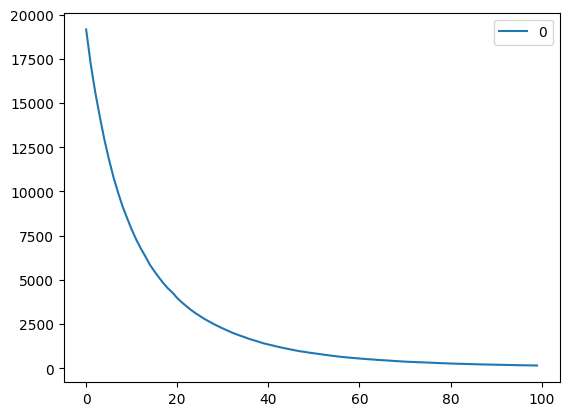

In [23]:
my_model.plot_loss


Кастомная модель -> Итоговый MSE на тесте: 0.27553
Sklearn модель   -> Итоговый MSE на тесте: 0.27567
Разница метрик: 0.0001401

Визуализация функции потерь


<Axes: >

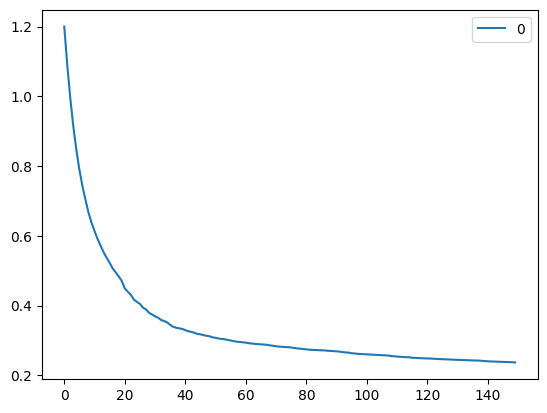

In [24]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

params = {'learning_rate': 0.1, 'n_estimators': 150, 'max_depth': 3,
          'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42}

my_model = GradientBoostingReg(**params, loss='mse').fit(X_train, y_train)
my_preds = my_model.predict(X_test)

sk_model = GradientBoostingRegressor(**params, loss='squared_error').fit(X_train, y_train)
sk_preds = sk_model.predict(X_test)

my_mse = mean_squared_error(y_test, my_preds)
sk_mse = mean_squared_error(y_test, sk_preds)

print(f"""
Кастомная модель -> Итоговый MSE на тесте: {my_mse:.5f}
Sklearn модель   -> Итоговый MSE на тесте: {sk_mse:.5f}
Разница метрик: {abs(my_mse - sk_mse):.7f}

Визуализация функции потерь""")

my_model.plot_loss

In [25]:
base_pred_sk = sk_model.init_.predict(X_train)[0]
print(f"Базовое предсказание в sklearn:          {base_pred_sk:.4f}")
print(f"Базовое предсказание в кастомной модели: {my_model.base_pred:.4f}")

Базовое предсказание в sklearn:          2.0719
Базовое предсказание в кастомной модели: 2.0719
